In [17]:
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib

#other model
import lightgbm as lgb
import time
import os
from joblib import Parallel, delayed
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

In [18]:
# Loading all crime data and clustering
df_crimes = pd.read_csv("../data/processed/all_data_uncleaned.csv").copy()
df_crimes = df_crimes.dropna(subset=["LSOA code"])
df_crimes = df_crimes.dropna(subset=["Crime type"])
df_crimes = df_crimes.dropna(subset=["Month"])
df_crimes = df_crimes.drop(columns=["Context"])

df_crimes["Month"] = pd.to_datetime(df_crimes["Month"])
# df_crimes["Month"] = df_crimes["Month"].dt.month

df_crimes = (df_crimes.groupby(["LSOA code", "Month", "Crime type"]).size().reset_index(name="crime_count"))
len(df_crimes)

2061728

In [19]:
df_crimes["crime_count"].median(), df_crimes["crime_count"].mean()

(2.0, 3.0714570496205127)

In [20]:
le_crime = LabelEncoder()
le_lsoa  = LabelEncoder()

df_crimes["crime_type_enc"] = le_crime.fit_transform(df_crimes["Crime type"].fillna("Unknown"))
df_crimes["lsoa_enc"]       = le_lsoa.fit_transform(df_crimes["LSOA code"].fillna("Unknown"))
df_crimes["month_num"]      = pd.to_datetime(df_crimes["Month"]).dt.month

train = df_crimes[df_crimes["Month"] < "2025-01-01"]
test  = df_crimes[df_crimes["Month"] >= "2025-01-01"]

features = ["crime_type_enc", "month_num", "lsoa_enc"]
target   = "crime_count"

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

model = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    gamma=0.1,
    random_state=42
)
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"RMSE: {rmse:.2f}")

RMSE: 5.26


In [21]:
joblib.dump(model, "../models/prediction_model.pkl")

['../models/prediction_model.pkl']

XGBoost LSOA performance plot saved successfully!


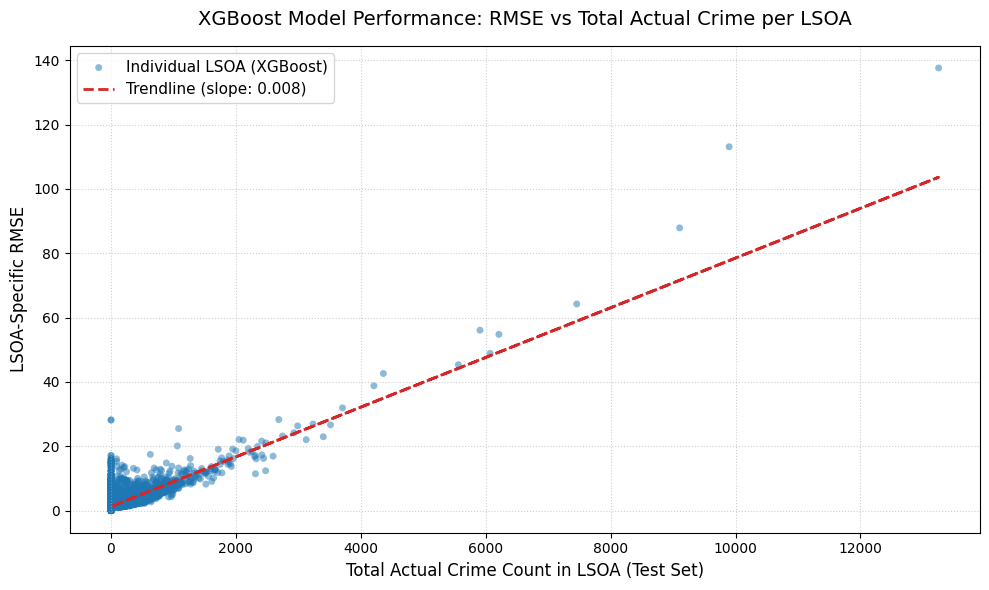

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

test_eval_xgb = test.copy()
test_eval_xgb['predicted_count'] = preds  

xgb_lsoa_stats = []

for lsoa, group in test_eval_xgb.groupby('LSOA code'):
    lsoa_rmse = np.sqrt(mean_squared_error(group['crime_count'], group['predicted_count']))
    total_actual_crime = group['crime_count'].sum()
    
    xgb_lsoa_stats.append({
        'LSOA code': lsoa,
        'RMSE': lsoa_rmse,
        'Total_Crime': total_actual_crime
    })

df_xgb_analysis = pd.DataFrame(xgb_lsoa_stats)


fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_xgb_analysis['Total_Crime'], df_xgb_analysis['RMSE'], 
           alpha=0.5, color='#1f77b4', edgecolors='none', s=25, label='Individual LSOA (XGBoost)')

m_xgb, b_xgb = np.polyfit(df_xgb_analysis['Total_Crime'], df_xgb_analysis['RMSE'], 1)
ax.plot(df_xgb_analysis['Total_Crime'], m_xgb * df_xgb_analysis['Total_Crime'] + b_xgb, 
        color='#d62728', linestyle='--', linewidth=2, label=f'Trendline (slope: {m_xgb:.3f})')

ax.set_title('XGBoost Model Performance: RMSE vs Total Actual Crime per LSOA', fontsize=14, pad=15)
ax.set_xlabel('Total Actual Crime Count in LSOA (Test Set)', fontsize=12)
ax.set_ylabel('LSOA-Specific RMSE', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()
print("XGBoost LSOA performance plot saved successfully!")

In [ ]:

# Generate predictions for every London LSOA x crime type x month (2025) and export to CSV
import itertools
import sys
sys.path.append("../../backend/services")
from crime_weight import crime_weights

lsoa_station = pd.read_csv("../data/shape/lsoa_station_map.csv", usecols=["LSOA21CD", "station"])
police_station = pd.read_csv("../data/shape/police_stations.csv", usecols=["station", "police_force"])

lsoa_station = (
    lsoa_station
    .merge(
        police_station,
        on="station",
        how="left"  
    )
    [["LSOA21CD", "station", "police_force"]]
)

all_lsoas       = df_crimes["LSOA code"].unique()
all_crime_types = df_crimes["Crime type"].unique()
months          = list(range(1, 13))

rows = list(itertools.product(all_lsoas, all_crime_types, months))
pred_df = pd.DataFrame(rows, columns=["LSOA code", "Crime type", "month_num"])
pred_df["year"] = 2025

pred_df["lsoa_enc"]       = le_lsoa.transform(pred_df["LSOA code"])
pred_df["crime_type_enc"] = le_crime.transform(pred_df["Crime type"])

pred_df["predicted_crime_count"] = model.predict(pred_df[["crime_type_enc", "month_num", "lsoa_enc"]])
pred_df["predicted_crime_count"] = pred_df["predicted_crime_count"].clip(lower=0).round().astype(int)

pred_df["severity_score"] = pred_df["Crime type"].map(crime_weights)
pred_df["predicted_crime_severity"] = pred_df["predicted_crime_count"] * pred_df["severity_score"]

pred_df = pred_df.merge(lsoa_station, left_on="LSOA code", right_on="LSOA21CD", how="inner").drop(columns="LSOA21CD")

out_df = pred_df[["LSOA code", "station", "police_force", "Crime type", "year", "month_num", "predicted_crime_count", "predicted_crime_severity"]].rename(columns={"month_num": "month"})
out_df = out_df[out_df["police_force"] == "metropolitan"]
out_path = "../data/processed/lsoa_crime_predictions.csv"
out_df.to_csv(out_path, index=False)
print(f"Saved {len(out_df):,} rows to {out_path}")
out_df.head(10)


Saved 1,445,136 rows to ../data/processed/lsoa_crime_predictions.csv


,LSOA code,station,police_force,Crime type,year,month,predicted_crime_count,predicted_crime_severity
0,E01000001,Islington Police Station,metropolitan,Burglary,2025,1,2,730.0
1,E01000001,Islington Police Station,metropolitan,Burglary,2025,2,2,730.0
2,E01000001,Islington Police Station,metropolitan,Burglary,2025,3,2,730.0
3,E01000001,Islington Police Station,metropolitan,Burglary,2025,4,2,730.0
4,E01000001,Islington Police Station,metropolitan,Burglary,2025,5,2,730.0
5,E01000001,Islington Police Station,metropolitan,Burglary,2025,6,2,730.0
6,E01000001,Islington Police Station,metropolitan,Burglary,2025,7,2,730.0
7,E01000001,Islington Police Station,metropolitan,Burglary,2025,8,2,730.0
8,E01000001,Islington Police Station,metropolitan,Burglary,2025,9,2,730.0
9,E01000001,Islington Police Station,metropolitan,Burglary,2025,10,2,730.0


In [24]:

import sys
sys.path.append("../../backend/services")
from budget_allocation import allocate_budget

budget_df = allocate_budget(
    predictions_path="../data/processed/lsoa_crime_predictions.csv",
    output_path="../data/processed/budget_allocation.csv",
)
print(f"Saved {len(budget_df):,} rows to ../data/processed/budget_allocation.csv")
budget_df.head(20)


Saved 22 rows to ../data/processed/budget_allocation.csv


,station,total_predicted_crime_severity,mental_health,social_services,negotiator,k9,swat,base_allocation_pct
0,Acton Police Station,5294614.50,2.1782,2.1738,1.9963,1.9960,2.1043,2.1005
1,Bethnal Green Police Station,6358296.25,2.5020,2.4645,2.4039,2.4476,2.5167,2.5225
2,Brixton Police Station,6140018.00,2.3611,2.3143,2.1994,2.3897,2.3803,2.4359
3,Bromley Police Station,11368991.75,4.5574,4.5560,4.6516,4.7621,4.4114,4.5103
4,Charing Cross Police Station,5612419.50,2.1897,2.1372,2.2855,2.2254,2.2416,2.2266
5,Chingford Police Station,13523587.50,5.3816,5.4608,5.6059,5.3796,5.4560,5.3651
6,Colindale Police Station,18567309.25,7.4308,7.4766,7.6865,7.6845,7.3011,7.3661
7,Croydon Police Station,9958285.00,3.8417,3.8056,3.7235,3.9412,3.8920,3.9507
8,Dagenham Police Station,29200483.00,11.5990,11.7910,12.1400,11.6348,11.7916,11.5845
9,Edmonton Police Station,10782131.75,4.3195,4.3058,4.1186,4.1778,4.2661,4.2775


In [25]:
CHECKPOINT_PATH = "../models/sarima_predictions.csv"

def fit_one_series(lsoa, crime, train_group, test_df):
    try:
        test_group = test_df[
            (test_df["LSOA code"] == lsoa) &
            (test_df["Crime type"] == crime)
        ]

        if len(test_group) == 0 or len(train_group) < 24:
            return None

        train_ts = (
            train_group.set_index("Month")
            .asfreq("MS")["crime_count"]
            .fillna(0)
        )

        test_ts = (
            test_group.set_index("Month")
            .asfreq("MS")["crime_count"]
            .fillna(0)
        )

        model = SARIMAX(
            train_ts,
            order=(1, 0, 0),         
            seasonal_order=(0, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )

        result = model.fit(disp=False)
        forecast = np.clip(
            result.forecast(steps=len(test_ts)),
            0,
            None
        )

        return pd.DataFrame({
            "LSOA code": lsoa,
            "Crime type": crime,
            "Month": test_ts.index,
            "y_true": test_ts.values,
            "y_pred": forecast.values,
        })

    except Exception:
        return None


def train_fast_sarima(
    data_path="../data/processed/all_data_uncleaned.csv",
    top_n_lsoas=1000,
    n_jobs=-1
):
    start = time.time()

    df = pd.read_csv(data_path, low_memory=False)
    df = df.dropna(subset=["LSOA code", "Crime type", "Month"])
    df["Month"] = pd.to_datetime(df["Month"])

    # Aggregate
    df = (
        df.groupby(["LSOA code", "Crime type", "Month"])
        .size()
        .reset_index(name="crime_count")
    )

    # Train/test split
    train_df = df[df["Month"] < "2025-01-01"]
    test_df = df[df["Month"] >= "2025-01-01"]

    np.random.seed(42)
    all_lsoas = train_df["LSOA code"].dropna().unique()
    top_lsoas = np.random.choice(
        all_lsoas,
        size=top_n_lsoas,
        replace=False
    )

    train_df = train_df[train_df["LSOA code"].isin(top_lsoas)]
    test_df = test_df[test_df["LSOA code"].isin(top_lsoas)]

    grouped = list(train_df.groupby(["LSOA code", "Crime type"]))

    print(f"Series to process: {len(grouped)}")
    print(f"Using {n_jobs} CPU cores")

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(fit_one_series)(lsoa, crime, group, test_df)
        for (lsoa, crime), group in grouped
    )

    results = [r for r in results if r is not None]

    final_df = pd.concat(results, ignore_index=True)

    rmse = np.sqrt(mean_squared_error(
        final_df["y_true"], final_df["y_pred"]
    ))

    print("\n===== RESULTS =====")
    print(f"RMSE: {rmse:.2f}")
    print(f"Time: {(time.time() - start)/60:.1f} min")

    os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
    final_df.to_csv(CHECKPOINT_PATH, index=False)

    print(f"Saved to {CHECKPOINT_PATH}")

train_fast_sarima()

Series to process: 9429
Using -1 CPU cores

===== RESULTS =====
RMSE: 5.97
Time: 0.6 min
Saved to ../models/sarima_predictions.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../models/sarima_fast_predictions.csv")

df["Month"] = pd.to_datetime(df["Month"])

monthly = df.groupby("Month")[["y_true", "y_pred"]].sum().reset_index()

plt.figure()
plt.plot(monthly["Month"], monthly["y_true"], label="Actual")
plt.plot(monthly["Month"], monthly["y_pred"], label="Predicted")

plt.title("Actual vs Predicted Crime Count (Monthly)")
plt.xlabel("Month")
plt.ylabel("Crime count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../models/sarima_fast_predictions.csv'

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_crime_type_comparison(checkpoint_path="../models/sarima_fast_predictions.csv", output_path="crime_type_comparison.png"):
    if not os.path.exists(checkpoint_path):
        print(f"Error: Checkpoint file not found at {checkpoint_path}")
        return

    df = pd.read_csv(checkpoint_path)

    crime_df = df.groupby("Crime type")[["y_true", "y_pred"]].sum().reset_index()

    crime_df = crime_df.sort_values(by="y_true", ascending=False)

    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(crime_df))
    width = 0.35

    rects1 = ax.bar(x - width/2, crime_df["y_true"], width, label="Actual ($y_{\\text{true}}$)", color="#1f77b4")
    rects2 = ax.bar(x + width/2, crime_df["y_pred"], width, label="Predicted ($y_{\\text{pred}}$)", color="#ff7f0e")

    ax.set_ylabel("Total Crime Count", fontsize=12)
    ax.set_title("Actual vs. Predicted Crime Counts by Crime Type", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(crime_df["Crime type"], rotation=45, ha="right", fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    print(f"Chart successfully saved to {output_path}")


plot_crime_type_comparison()

Error: Checkpoint file not found at ../models/sarima_fast_predictions.csv


In [28]:
df_crimes = pd.read_csv("../data/processed/all_data_uncleaned.csv").copy()
df_crimes = df_crimes.dropna(subset=["LSOA code", "Crime type", "Month"])
df_crimes = df_crimes.drop(columns=["Context"])

df_crimes["Month"] = pd.to_datetime(df_crimes["Month"])
df_crimes = df_crimes.groupby(["LSOA code", "Month", "Crime type"]).size().reset_index(name="crime_count")


le_crime = LabelEncoder()
le_lsoa  = LabelEncoder()

df_crimes["crime_type_enc"] = le_crime.fit_transform(df_crimes["Crime type"].fillna("Unknown"))
df_crimes["lsoa_enc"]       = le_lsoa.fit_transform(df_crimes["LSOA code"].fillna("Unknown"))
df_crimes["month_num"]      = df_crimes["Month"].dt.month

train = df_crimes[df_crimes["Month"] < "2025-01-01"]
test  = df_crimes[df_crimes["Month"] >= "2025-01-01"]

features = ["crime_type_enc", "month_num", "lsoa_enc"]
target   = "crime_count"

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=["crime_type_enc", "lsoa_enc"])
test_data  = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=["crime_type_enc", "lsoa_enc"])

params = {
    "objective": "poisson",
    "metric": "poisson",
    "learning_rate": 0.03,
    "max_depth": 4,
    "num_leaves": 15,
    "min_data_in_leaf": 10,
    "bagging_fraction": 0.7,
    "bagging_freq": 1,
    "feature_fraction": 0.7,
    "lambda_l1": 0.1,
    "lambda_l2": 1.5,
    "seed": 42,
    "verbose": -1
}

num_round = 800
model_lgb = lgb.train(
    params,
    train_data,
    num_boost_round=num_round,
    valid_sets=[test_data]
)

preds = model_lgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"\nLightGBM RMSE: {rmse:.2f}")


LightGBM RMSE: 4.41


In [29]:
joblib.dump(model_lgb, "../models/prediction_model_lightgbm.pkl")

['../models/prediction_model_lightgbm.pkl']

XGBOOST VS LIGHTGBM

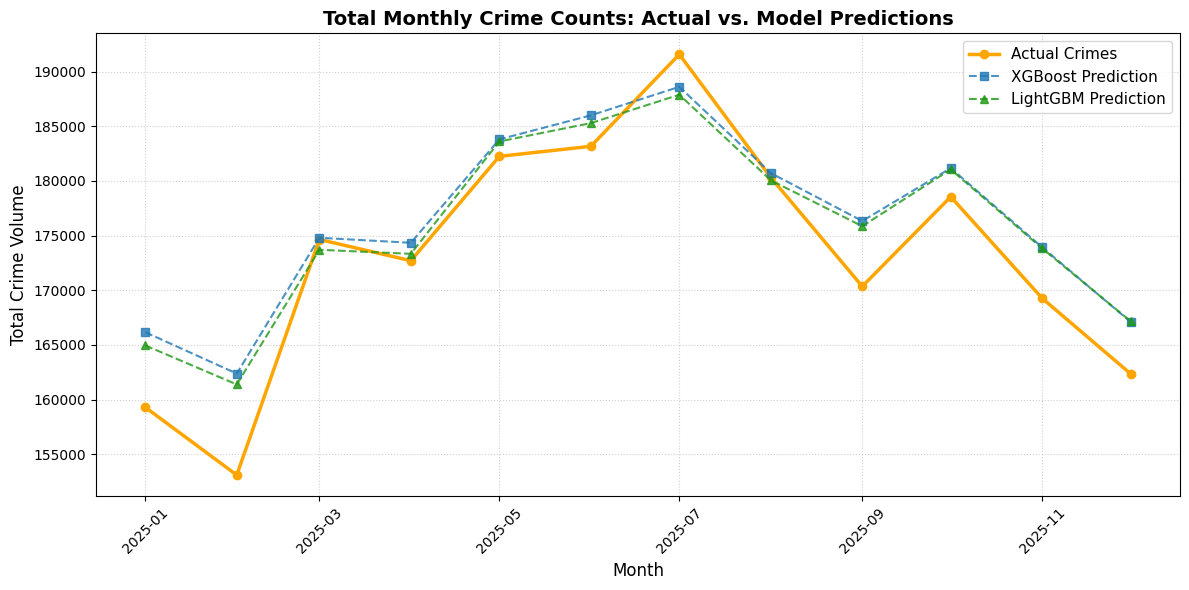

In [32]:
import matplotlib.pyplot as plt

df_plot = test.copy()

df_plot["xgb_pred"] = model.predict(X_test)
df_plot["lgb_pred"] = model_lgb.predict(X_test)

monthly_summary = (
    df_plot.groupby("Month")[["crime_count", "xgb_pred", "lgb_pred"]]
    .sum()
    .reset_index()
)
monthly_summary = monthly_summary.sort_values("Month")


plt.figure(figsize=(12, 6))
plt.plot(
    monthly_summary["Month"],
    monthly_summary["crime_count"],
    label="Actual Crimes",
    color="orange",
    marker="o",
    linewidth=2.5,
)

# XGboost
plt.plot(
    monthly_summary["Month"],
    monthly_summary["xgb_pred"],
    label="XGBoost Prediction",
    color="#1f77b4",
    marker="s",
    linestyle="--",
    alpha=0.8,
)

# LightGBM
plt.plot(
    monthly_summary["Month"],
    monthly_summary["lgb_pred"],
    label="LightGBM Prediction",
    color="#1f9714",
    marker="^",
    linestyle="--",
    alpha=0.8,
)


plt.title("Total Monthly Crime Counts: Actual vs. Model Predictions", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Crime Volume", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

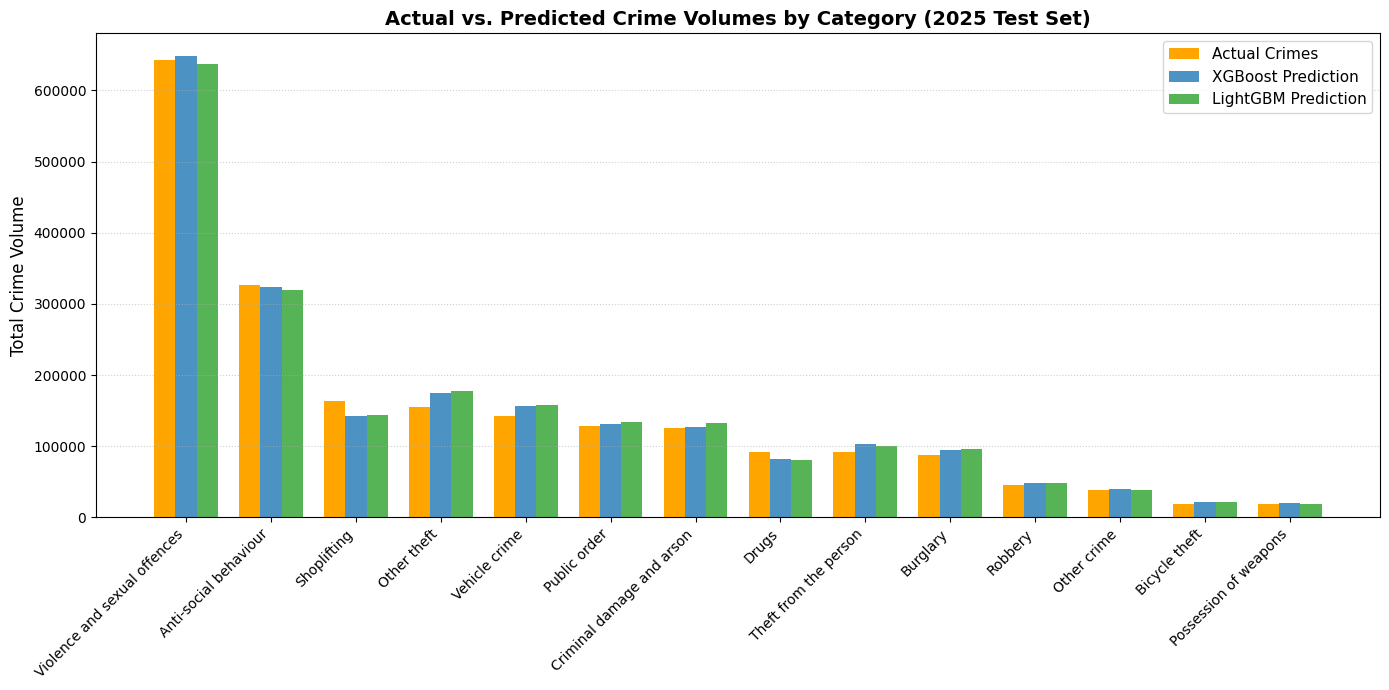

In [33]:
category_summary = (
    df_plot.groupby("Crime type")[["crime_count", "xgb_pred", "lgb_pred"]]
    .sum()
    .reset_index()
)
category_summary = category_summary.sort_values(
    by="crime_count", ascending=False
)

x = np.arange(len(category_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(
    x - width,
    category_summary["crime_count"],
    width,
    label="Actual Crimes",
    color="orange",
)
ax.bar(
    x,
    category_summary["xgb_pred"],
    width,
    label="XGBoost Prediction",
    color="#1f77b4",
    alpha=0.8,
)
ax.bar(
    x + width,
    category_summary["lgb_pred"],
    width,
    label="LightGBM Prediction",
    color="#2ca02c",
    alpha=0.8,
)

ax.set_ylabel("Total Crime Volume", fontsize=12)
ax.set_title(
    "Actual vs. Predicted Crime Volumes by Category (2025 Test Set)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(
    category_summary["Crime type"], rotation=45, ha="right", fontsize=10
)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

LSOA performance plot saved successfully!


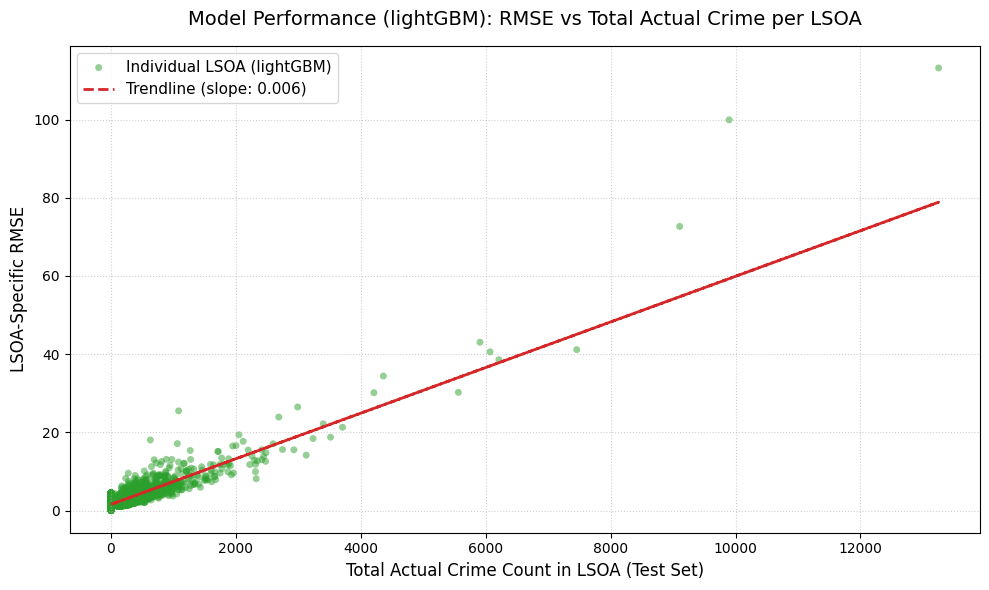

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

test_eval = test.copy()
test_eval['predicted_count'] = preds


lsoa_stats = []
for lsoa, group in test_eval.groupby('LSOA code'):
    lsoa_rmse = np.sqrt(mean_squared_error(group['crime_count'], group['predicted_count']))
    total_actual_crime = group['crime_count'].sum()
    
    lsoa_stats.append({
        'LSOA code': lsoa,
        'RMSE': lsoa_rmse,
        'Total_Crime': total_actual_crime
    })

df_lsoa_analysis = pd.DataFrame(lsoa_stats)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_lsoa_analysis['Total_Crime'], df_lsoa_analysis['RMSE'], 
           alpha=0.5, color='#2ca02c', edgecolors='none', s=25, label='Individual LSOA (lightGBM)')

m, b = np.polyfit(df_lsoa_analysis['Total_Crime'], df_lsoa_analysis['RMSE'], 1)
ax.plot(df_lsoa_analysis['Total_Crime'], m * df_lsoa_analysis['Total_Crime'] + b, 
        color='#d62728', linestyle='--', linewidth=2, label=f'Trendline (slope: {m:.3f})')

ax.set_title('Model Performance (lightGBM): RMSE vs Total Actual Crime per LSOA', fontsize=14, pad=15)
ax.set_xlabel('Total Actual Crime Count in LSOA (Test Set)', fontsize=12)
ax.set_ylabel('LSOA-Specific RMSE', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()

print("LSOA performance plot saved successfully!")

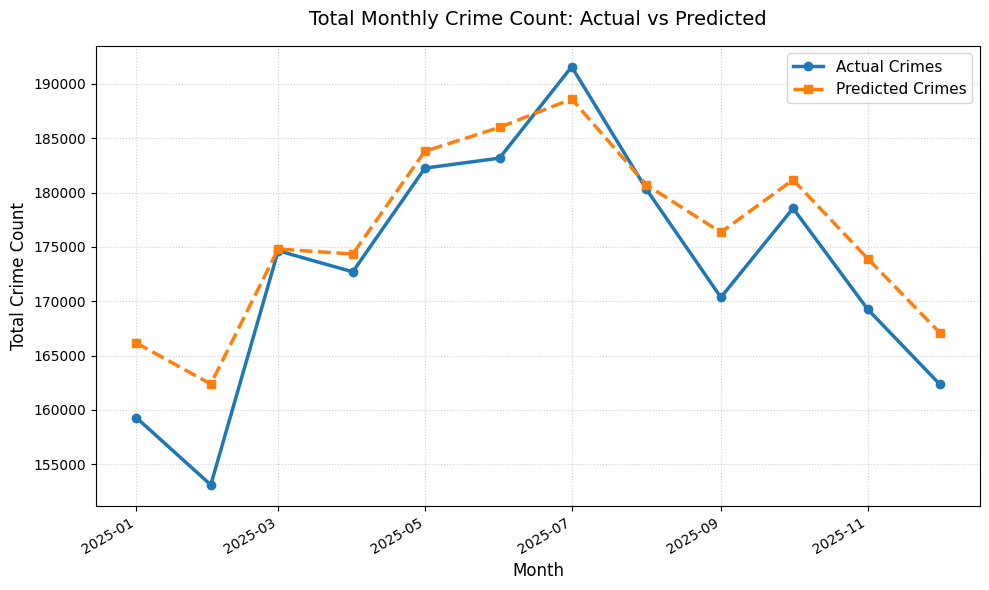

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

test_plot = test.copy()
test_plot['predicted_count'] = preds

monthly_df = test_plot.groupby('Month')[['crime_count', 'predicted_count']].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(monthly_df['Month'], monthly_df['crime_count'], marker='o', color='#1f77b4', linewidth=2.5, label='Actual Crimes')
ax.plot(monthly_df['Month'], monthly_df['predicted_count'], marker='s', color='#ff7f0e', linestyle='--', linewidth=2.5, label='Predicted Crimes')

ax.set_title('Total Monthly Crime Count: Actual vs Predicted', fontsize=14, pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Crime Count', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=11)

fig.autofmt_xdate()

plt.tight_layout()